# Masters: economics you can inspect
Prepared 8 October 2026. **Scenario model, not a sales forecast.**

The base offer is a hypothesis: INR 599 for five capped practice sessions. No measured demand, CAC or repeat-purchase data is implied. This notebook imports the accompanying `economics.py`; the browser calculator implements the same formulas independently.

Read [pricing and economics](03_PRICING_AND_ECONOMICS.md) for vendor sources and exclusions. Run with Python 3, Jupyter/ipykernel and Matplotlib from this directory. No network calls, credentials or applicant data are used.

In [1]:
from dataclasses import asdict, replace
from IPython.display import display, Markdown
from economics import Assumptions, evaluate, validate
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
a = Assumptions()

def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines += ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in rows]
    display(Markdown('\n'.join(lines)))

table(['Input', 'Base assumption'], asdict(a).items())

| Input | Base assumption |
| --- | --- |
| price_inr | 599 |
| sales_tax_rate | 0.18 |
| refund_rate | 0.03 |
| gateway_rate | 0.0236 |
| sessions_per_pack | 5 |
| reserved_cost_per_session_inr | 25 |
| support_provision_per_pack_inr | 20 |
| acquisition_cost_per_pack_inr | 100 |
| fixed_monthly_inr | 4000 |
| free_trial_budget_monthly_inr | 1000 |
| founder_hours_monthly | 20 |
| founder_hour_value_inr | 750 |

## Method and boundaries
Net sales = price × (1 − refund allowance) ÷ (1 + sales tax).
Contribution = net sales − gateway fee on gross price − full session allowance − cash support provision − acquisition.
Monthly planning surplus = paid packs × contribution − fixed overhead − free-trial budget.

The 18% sales-tax input is an illustration, not a determination of registration or liability. Gateway GST is a different cost. Every included session is reserved, including unused allowance; actual timing and accounting will differ. Founder time is shown separately at an assumed hourly value. If founder hours provide the support already budgeted as cash, remove the duplicate provision. One pack per buyer per month; admissions seasonality prevents interpreting this as subscription MRR.

In [2]:
volumes = [10, 25, 50, 100, 250]
rows = [evaluate(a, buyers=n) for n in volumes]
fmt = lambda x: f'{x:,.2f}'
table(['Monthly packs', 'Gross INR', 'Surplus before time INR', 'After time INR'],
      [(r['buyers'], fmt(r['gross_collections_inr']), fmt(r['planning_surplus_before_founder_time_inr']), fmt(r['planning_surplus_after_founder_time_inr'])) for r in rows])
base=evaluate(a)
print(f"Base contribution: INR {base['contribution_per_pack_inr']:.2f}; break-even: {base['break_even_buyers']} packs; INR 25,000 target before founder time: {base['buyers_for_target_income']} packs.")

| Monthly packs | Gross INR | Surplus before time INR | After time INR |
| --- | --- | --- | --- |
| 10 | 5,990.00 | -2,667.38 | -17,667.38 |
| 25 | 14,975.00 | 831.55 | -14,168.45 |
| 50 | 29,950.00 | 6,663.10 | -8,336.90 |
| 100 | 59,900.00 | 18,326.19 | 3,326.19 |
| 250 | 149,750.00 | 53,315.48 | 38,315.48 |

Base contribution: INR 233.26; break-even: 22 packs; INR 25,000 target before founder time: 129 packs.


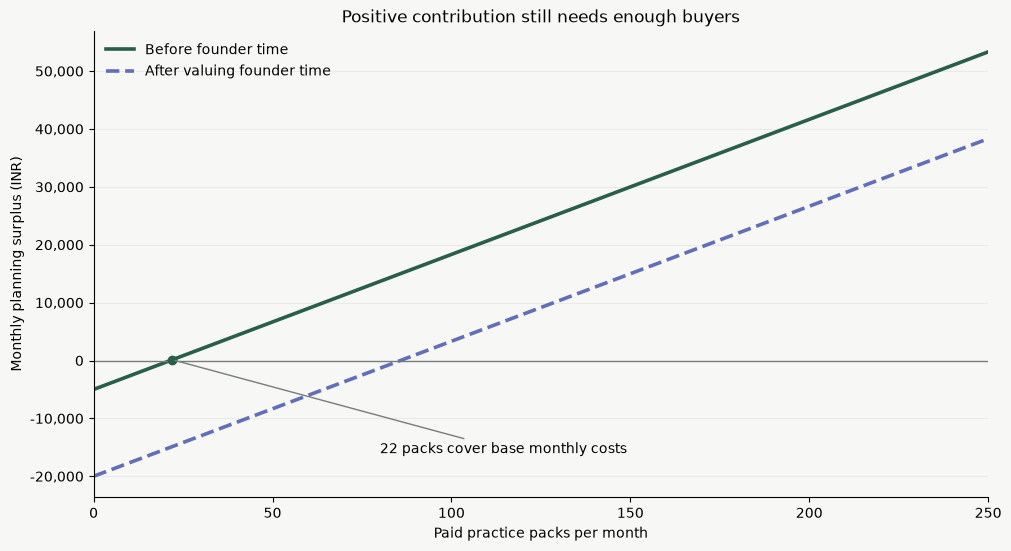

In [3]:
x = list(range(0, 251))
y_cash = [evaluate(a, buyers=n)['planning_surplus_before_founder_time_inr'] for n in x]
y_time = [evaluate(a, buyers=n)['planning_surplus_after_founder_time_inr'] for n in x]
fig, ax = plt.subplots(figsize=(10, 5.4), constrained_layout=True)
fig.patch.set_facecolor('#f7f8f5'); ax.set_facecolor('#f7f8f5')
ax.plot(x, y_cash, color='#285e4c', linewidth=2.6, label='Before founder time')
ax.plot(x, y_time, color='#626eb7', linewidth=2.6, linestyle='--', label='After valuing founder time')
ax.axhline(0, color='#767d7a', linewidth=1)
ax.scatter([22], [evaluate(a, buyers=22)['planning_surplus_before_founder_time_inr']], color='#285e4c', zorder=3)
ax.annotate('22 packs cover base monthly costs', xy=(22, 132), xytext=(80, -16000), fontsize=10, arrowprops={'arrowstyle':'-', 'color':'#767d7a'})
ax.set(title='Positive contribution still needs enough buyers', xlabel='Paid practice packs per month', ylabel='Monthly planning surplus (INR)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xlim(0,250); ax.grid(axis='y', alpha=.18); ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', frameon=False)
fig.savefig('economics-scenarios.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

The chart holds overhead and founder time constant to isolate volume. In reality, increase them as support and operational work rise. The gap is INR 15,000/month: 20 hours × INR 750/hour. The model excludes setup spending and income tax; it reserves a fixed INR 1,000/month free-trial budget that must actually be enforced.

In [4]:
table(['Acquisition INR/pack', 'Contribution INR', 'Break-even packs', 'Packs for INR 25,000'],
      [(c, fmt(r['contribution_per_pack_inr']), r['break_even_buyers'] if r['break_even_buyers'] is not None else 'Not viable', r['buyers_for_target_income'] if r['buyers_for_target_income'] is not None else 'Not viable')
       for c in [0, 100, 250, 400] for r in [evaluate(replace(a, acquisition_cost_per_pack_inr=c))]])
print(validate())
assert base['break_even_buyers'] == 22
assert base['buyers_for_target_income'] == 129
assert round(base['contribution_per_pack_inr'], 2) == 233.26
print('Published base-case figures reconcile.')

| Acquisition INR/pack | Contribution INR | Break-even packs | Packs for INR 25,000 |
| --- | --- | --- | --- |
| 0 | 333.26 | 16 | 91 |
| 100 | 233.26 | 22 | 129 |
| 250 | 83.26 | 61 | 361 |
| 400 | -66.74 | Not viable | Not viable |

Five boundary/reconciliation checks passed
Published base-case figures reconcile.


## What to measure next
1. Observe 10–20 applicants completing the actual practice flow; useful feedback comes before growth spending.
2. Measure provider cost per completed and failed session, including retries and transcription/speech. Replace INR 25 with a justified reserve for the enforced session limits.
3. Obtain independent paid purchases and measure acquisition cost over a mature refund window.
4. Log founder/support minutes, refunds and unused obligations.
5. Update the assumptions and rerun all cells. Expand a channel only when fully loaded contribution remains positive.

**Interpretation:** 22 packs covering the base operating envelope is arithmetic. It is not evidence that 22 people will buy. INR 25,000/month needs 129 packs under these assumptions, before founder time and income tax. At INR 400 acquisition cost, increasing volume makes losses larger.

[Roadmap index](README.md) · [Interactive calculator](economics-calculator.html) · [Sources](SOURCES.md)